# 0. Importing Libraries

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Setting Up the Device (CPU / GPU)

In [51]:
device =  torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# 2. Loading the MNIST Dataset

In [52]:
BATCH_SIZE = 128
data_transformation = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=data_transformation)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Defining the Autoencoder Architecture

In [53]:
# Class that defines autoencoders
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 128, hidden_dim = 256):
    super().__init__()

    # Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )

    # Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim,hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim,784),
        nn.Sigmoid()
    )

  def forward(self, x):
    z = self.encoder(x)
    x_reconstructed = self.decoder(z)
    return x_reconstructed

- nn.Module is our parent class, so we called super().__init__(), which will initialize the __init__ constructor in the parent class

# 4. Initializing Model, Loss Function, and Optimizer

In [54]:
# Defining the model and loss
model = AutoEncoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

# 5. Training the Autoencoder

In [55]:
epochs = 25

model.to(device) # Move the model to the specified device
model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad() # for each batch it start with gradient = 0
    x_reconstructed = model(x)
    loss = criterion(x_reconstructed, x)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch [{epoch + 1} / {epochs}], Loss: {avg_loss:.6f}")

Epoch [1 / 25], Loss: 0.042013
Epoch [2 / 25], Loss: 0.015748
Epoch [3 / 25], Loss: 0.011147
Epoch [4 / 25], Loss: 0.008968
Epoch [5 / 25], Loss: 0.007626
Epoch [6 / 25], Loss: 0.006662
Epoch [7 / 25], Loss: 0.005972
Epoch [8 / 25], Loss: 0.005464
Epoch [9 / 25], Loss: 0.005085
Epoch [10 / 25], Loss: 0.004733
Epoch [11 / 25], Loss: 0.004438
Epoch [12 / 25], Loss: 0.004189
Epoch [13 / 25], Loss: 0.003975
Epoch [14 / 25], Loss: 0.003798
Epoch [15 / 25], Loss: 0.003609
Epoch [16 / 25], Loss: 0.003477
Epoch [17 / 25], Loss: 0.003357
Epoch [18 / 25], Loss: 0.003231
Epoch [19 / 25], Loss: 0.003153
Epoch [20 / 25], Loss: 0.003053
Epoch [21 / 25], Loss: 0.002978
Epoch [22 / 25], Loss: 0.002906
Epoch [23 / 25], Loss: 0.002834
Epoch [24 / 25], Loss: 0.002771
Epoch [25 / 25], Loss: 0.002707


# 6. Visualizing Original vs. Reconstructed Images

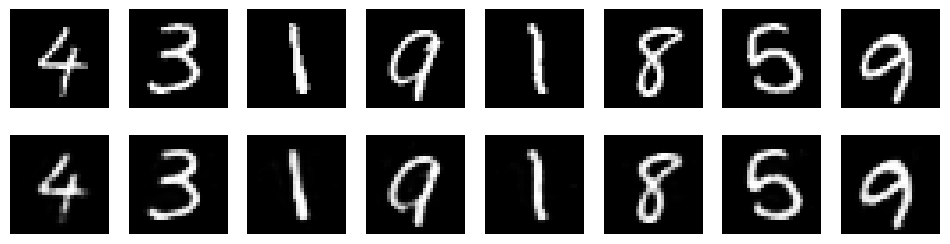

In [56]:
model.eval()

with torch.no_grad():
  x, _ = next(iter(train_loader))
  x = x.view(-1, 784).to(device)
  x_reconstructed = model(x)

  n = 8
  plt.figure(figsize = (12,3))

  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].cpu().view(28,28), cmap = "gray")
    plt.axis("off")

    plt.subplot(2,n, i+n+1)
    plt.imshow(x_reconstructed[i].cpu().view(28,28), cmap = "gray")
    plt.axis("off")

  plt.show()

# 7. Extracting Latent Representations

In [57]:
model.eval()

latents = []
labels  = []

with torch.no_grad():
  for x,y in train_loader:
    x = x.view(-1, 784).to(device)
    x = model.encoder(x)

    latents.append(x.cpu().numpy())
    labels.append(y.numpy())

latents = np.concatenate(latents, axis = 0)
labels = np.concatenate(labels, axis = 0)

# 8. Visualizing Latent Space

In [58]:
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA

latent_dim = latents.shape[1]

# Ensuring numpy
z = latents
y = labels

if latent_dim == 1:
  # Histogram
  plt.figure(figsize = (10,10))
  for digit in range(10):
    plt.hist(
        z[y == digit].flatten(),
        bins = 50,
        alpha = 0.5,
        label = str(digit)
    )

  plt.xlabel("Latent Space")
  plt.ylabel("Frequency")
  plt.title("1D Distribution by Class")
  plt.legend()
  plt.show()

elif latent_dim == 2:
  # Scatter Plot
  plt.figure(figsize = (10,10))
  scatter = plt.scatter(
    z[:,0], z[:,1],
    c = y,
    cmap = "tab10",
    s = 5,
    alpha = 0.7
  )
  plt.colorbar(scatter, ticks=range(10))
  plt.xlabel("z1")
  plt.ylabel("z2")
  plt.title("2D Latent Space")
  plt.show()

elif latent_dim == 3:
  # 3D Rotatable Scatter with Plotly
  fig = px.scatter_3d(
      x=z[:, 0], y=z[:, 1], z=z[:, 2],
      color=y.astype(str), # Converting labels to string for distinct colors
      color_discrete_sequence=px.colors.qualitative.Plotly,
      title="3D Latent Space"
  )
  fig.update_layout(scene=dict(
      xaxis_title="z1",
      yaxis_title="z2",
      zaxis_title="z3"
  ))
  fig.show()

else:
  # For latent_dim > 3, performing PCA
  pca_dim = 3
  pca = PCA(n_components = pca_dim)
  z_pca = pca.fit_transform(z)

  if pca_dim == 2:
    plt.figure(figsize = (10,10))
    scatter = plt.scatter(
    z_pca[:,0], z_pca[:,1],
    c = y,
    cmap = "tab10",
    s = 5,
    alpha = 0.7
  )
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA Projection of Latent Space ({pca_dim}D)")
    plt.show()

  elif pca_dim == 3:
    # 3D PCA Rotatable Scatter with Plotly
    fig = px.scatter_3d(
        x=z_pca[:, 0], y=z_pca[:, 1], z=z_pca[:, 2],
        color=y.astype(str), # Convert labels to string for distinct colors
        color_discrete_sequence=px.colors.qualitative.Plotly,
        title=f"PCA Projection of Latent Space ({pca_dim}D)"
    )
    fig.update_layout(scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ))
    fig.show()

# 9. Evaluating Cluster Separation (Silhouette Score)

In [59]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
sil_score = silhouette_score(z, y)

print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.0227


## 10. Generating Images from Random Latent Vectors

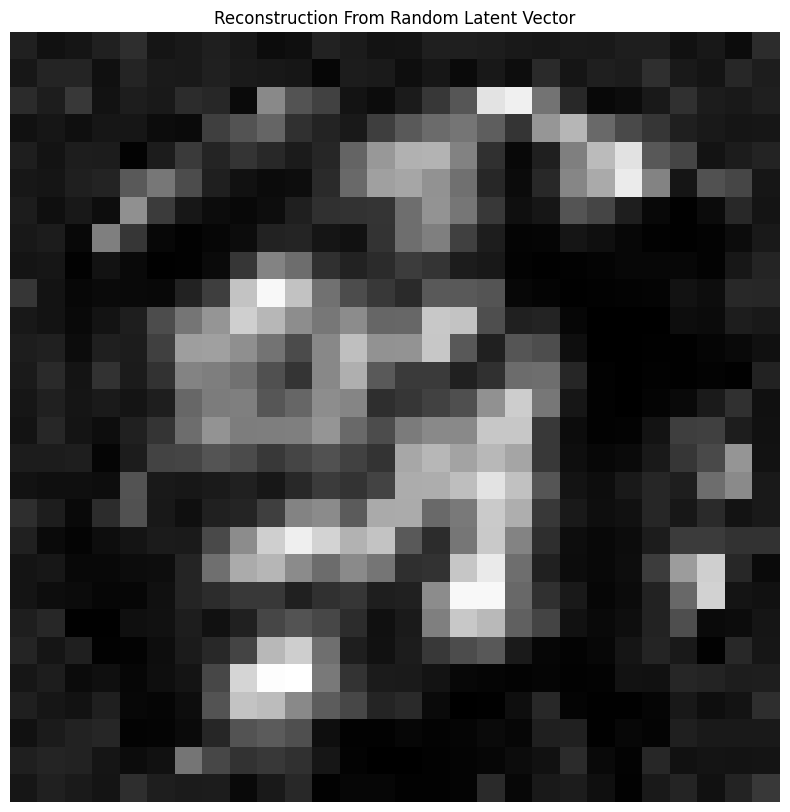

In [60]:
model.eval()

with torch.no_grad():
  latent_dim = model.encoder[-2].out_features
  z_random = torch.randn(10, latent_dim).to(device)
  x_reconstructed = model.decoder(z_random)
  x_reconstructed = x_reconstructed[0].cpu().view(28,28)

plt.figure(figsize = (10,10))
plt.imshow(x_reconstructed, cmap = "gray")
plt.axis("off")
plt.title("Reconstruction From Random Latent Vector")
plt.show()